In [1]:
import os, time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(2)
out_dir='/mnt/data/exp6_work'
os.makedirs(out_dir, exist_ok=True)
device='cpu'
print('PyTorch:', torch.__version__)
print('Device:', device)

PyTorch: 2.10.0+cpu
Device: cpu


In [2]:
classes=['WALKING','WALKING_UPSTAIRS','WALKING_DOWNSTAIRS','SITTING','STANDING','LAYING']
T=128
F=9
n_per_class=120
t=np.linspace(0,4*np.pi,T)
X=[]
y=[]
for c in range(6):
    for i in range(n_per_class):
        phase=np.random.uniform(-0.4,0.4)
        noise=np.random.normal(0,0.10,(T,F))
        s=np.zeros((T,F),dtype=np.float32)
        if c==0:
            base=np.sin(1.8*t+phase)
            for f in range(F): s[:,f]=(0.55+0.05*f)*np.sin((1.65+0.04*f)*t+phase+0.15*f)
        elif c==1:
            for f in range(F): s[:,f]=(0.72+0.04*f)*np.sin((2.15+0.04*f)*t+phase+0.12*f)+0.12*np.maximum(0,np.sin(0.55*t))
        elif c==2:
            for f in range(F): s[:,f]=(0.68+0.04*f)*np.sin((2.35+0.03*f)*t+phase+0.18*f)-0.10*np.maximum(0,np.sin(0.55*t))
        elif c==3:
            for f in range(F): s[:,f]=0.08*np.sin((0.28+0.02*f)*t+phase)+0.03*f
        elif c==4:
            for f in range(F): s[:,f]=0.05*np.sin((0.22+0.015*f)*t+phase)+0.07*f
        else:
            for f in range(F): s[:,f]=0.04*np.sin((0.18+0.01*f)*t+phase)-0.06*f
        s+=noise*(0.75 if c<3 else 0.22)
        X.append(s)
        y.append(c)
X=np.array(X,dtype=np.float32)
y=np.array(y,dtype=np.int64)
idx_train,idx_tmp=train_test_split(np.arange(len(y)),test_size=0.30,stratify=y,random_state=seed)
idx_val,idx_test=train_test_split(idx_tmp,test_size=0.50,stratify=y[idx_tmp],random_state=seed)
mu=X[idx_train].mean(axis=(0,1),keepdims=True)
sd=X[idx_train].std(axis=(0,1),keepdims=True)+1e-6
Xn=(X-mu)/sd
X_train,y_train=Xn[idx_train],y[idx_train]
X_val,y_val=Xn[idx_val],y[idx_val]
X_test,y_test=Xn[idx_test],y[idx_test]
print('Input tensor shape:')
print('Training   :',X_train.shape)
print('Validation :',X_val.shape)
print('Testing    :',X_test.shape)
print('Number of classes:',len(classes))
print('Number of features per time step:',F)
print('Sequence length:',T)
print('Class counts:',dict(zip(classes,np.bincount(y_train).tolist())))

Input tensor shape:
Training   : (504, 128, 9)
Validation : (108, 128, 9)
Testing    : (108, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128
Class counts: {'WALKING': 84, 'WALKING_UPSTAIRS': 84, 'WALKING_DOWNSTAIRS': 84, 'SITTING': 84, 'STANDING': 84, 'LAYING': 84}


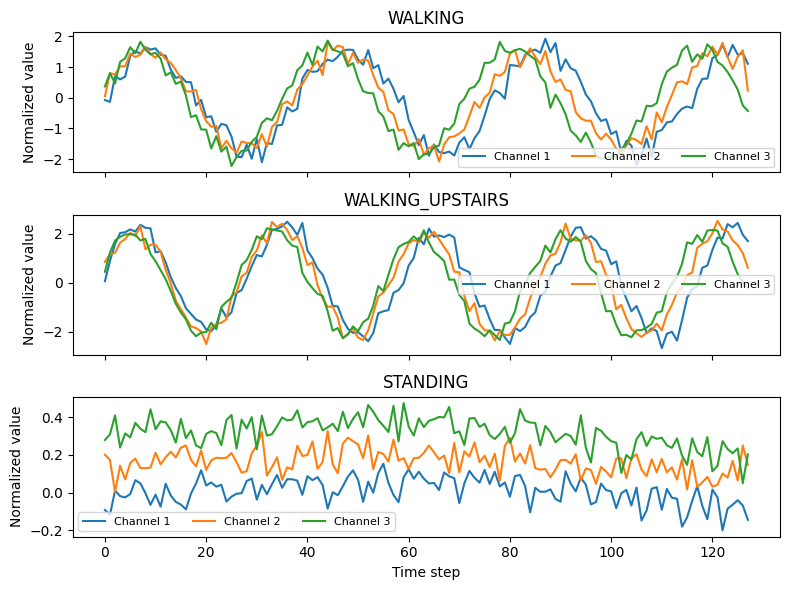

In [3]:
fig,axs=plt.subplots(3,1,figsize=(8,6),sharex=True)
for ax,c in zip(axs,[0,1,4]):
    k=np.where(y_test==c)[0][0]
    for ch in range(3): ax.plot(np.arange(T),X_test[k,:,ch],label=f'Channel {ch+1}')
    ax.set_title(classes[c])
    ax.set_ylabel('Normalized value')
    ax.legend(ncol=3,fontsize=8)
axs[-1].set_xlabel('Time step')
plt.tight_layout()
plt.savefig(f'{out_dir}/sensor_sequences.png',dpi=160)
plt.show()

In [4]:
x=[0.5,0.7,0.2]
h=0.0
vals=[]
for xt in x:
    h=np.tanh(0.5*xt+0.8*h+0.1)
    vals.append(h)
print('h1 =',round(vals[0],6))
print('h2 =',round(vals[1],6))
print('h3 =',round(vals[2],6))

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


In [5]:
class SeqClassifier(nn.Module):
    def __init__(self,kind,input_size=9,hidden=32,classes=6):
        super().__init__()
        if kind=='RNN': self.rec=nn.RNN(input_size,hidden,batch_first=True)
        elif kind=='LSTM': self.rec=nn.LSTM(input_size,hidden,batch_first=True)
        else: self.rec=nn.GRU(input_size,hidden,batch_first=True)
        self.drop=nn.Dropout(0.2)
        self.fc1=nn.Linear(hidden,16)
        self.fc2=nn.Linear(16,classes)
    def forward(self,x):
        z,_=self.rec(x)
        z=self.drop(z[:,-1])
        z=torch.relu(self.fc1(z))
        return self.fc2(z)

def loaders(Xa,ya,Xb,yb,bs=32):
    tr=DataLoader(TensorDataset(torch.tensor(Xa),torch.tensor(ya)),batch_size=bs,shuffle=True)
    va=DataLoader(TensorDataset(torch.tensor(Xb),torch.tensor(yb)),batch_size=bs)
    return tr,va

def train_model(kind,Xtr,ytr,Xv,yv,epochs=12):
    model=SeqClassifier(kind,input_size=Xtr.shape[2])
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    lossfn=nn.CrossEntropyLoss()
    tr,va=loaders(Xtr,ytr,Xv,yv)
    hist={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    st=time.perf_counter()
    for ep in range(epochs):
        model.train(); ls=[]; pr=[]; gt=[]
        for xb,yb in tr:
            opt.zero_grad(); o=model(xb); l=lossfn(o,yb); l.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step()
            ls.append(l.item()*len(yb)); pr.extend(o.argmax(1).tolist()); gt.extend(yb.tolist())
        model.eval(); vls=[]; vpr=[]; vgt=[]
        with torch.no_grad():
            for xb,yb in va:
                o=model(xb); l=lossfn(o,yb); vls.append(l.item()*len(yb)); vpr.extend(o.argmax(1).tolist()); vgt.extend(yb.tolist())
        hist['train_loss'].append(sum(ls)/len(gt)); hist['val_loss'].append(sum(vls)/len(vgt)); hist['train_acc'].append(accuracy_score(gt,pr)); hist['val_acc'].append(accuracy_score(vgt,vpr))
    return model,hist,time.perf_counter()-st

def evaluate(model,Xa,ya):
    model.eval()
    with torch.no_grad(): p=model(torch.tensor(Xa)).argmax(1).numpy()
    acc=accuracy_score(ya,p)
    prec,rec,f1,_=precision_recall_fscore_support(ya,p,average='macro',zero_division=0)
    cm=confusion_matrix(ya,p)
    return acc,prec,rec,f1,cm,p

models={}; histories={}; metrics={}
for kind in ['RNN','LSTM','GRU']:
    m,h,tm=train_model(kind,X_train,y_train,X_val,y_val,8)
    acc,prec,rec,f1,cm,p=evaluate(m,X_test,y_test)
    params=sum(q.numel() for q in m.parameters() if q.requires_grad)
    models[kind]=m; histories[kind]=h; metrics[kind]={'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1,'Parameters':params,'TrainingTime':tm,'CM':cm}
    print(kind, {k:(round(v,4) if isinstance(v,float) else v) for k,v in metrics[kind].items() if k!='CM'})

RNN {'Accuracy': 0.8611, 'Precision': 0.9242, 'Recall': 0.8611, 'F1': 0.8319, 'Parameters': 2006, 'TrainingTime': 1.06}


LSTM {'Accuracy': 0.8333, 'Precision': 0.75, 'Recall': 0.8333, 'F1': 0.7778, 'Parameters': 6134, 'TrainingTime': 1.1686}


GRU {'Accuracy': 0.8981, 'Precision': 0.9079, 'Recall': 0.8981, 'F1': 0.8955, 'Parameters': 4758, 'TrainingTime': 2.5613}


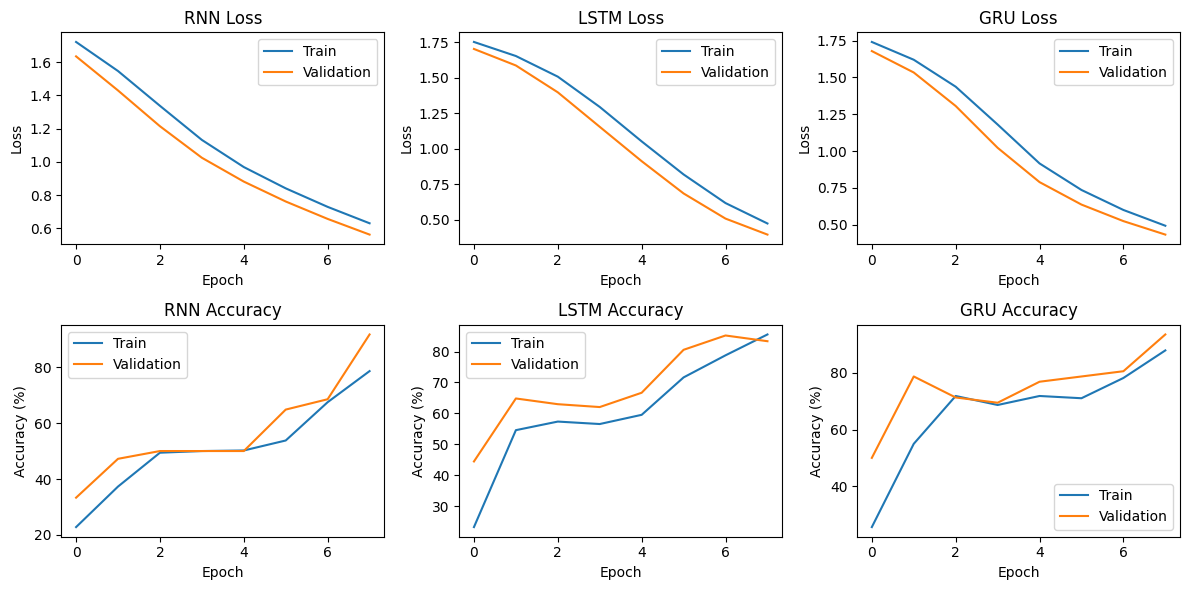

In [6]:
fig,axs=plt.subplots(2,3,figsize=(12,6))
for j,kind in enumerate(['RNN','LSTM','GRU']):
    h=histories[kind]
    axs[0,j].plot(h['train_loss'],label='Train'); axs[0,j].plot(h['val_loss'],label='Validation'); axs[0,j].set_title(f'{kind} Loss'); axs[0,j].set_xlabel('Epoch'); axs[0,j].set_ylabel('Loss'); axs[0,j].legend()
    axs[1,j].plot(np.array(h['train_acc'])*100,label='Train'); axs[1,j].plot(np.array(h['val_acc'])*100,label='Validation'); axs[1,j].set_title(f'{kind} Accuracy'); axs[1,j].set_xlabel('Epoch'); axs[1,j].set_ylabel('Accuracy (%)'); axs[1,j].legend()
plt.tight_layout(); plt.savefig(f'{out_dir}/training_curves.png',dpi=160); plt.show()

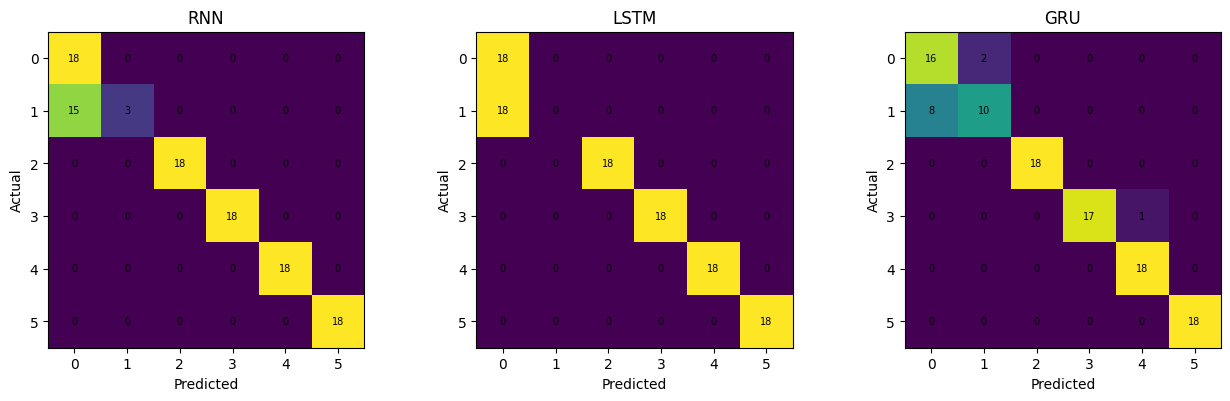

In [7]:
fig,axs=plt.subplots(1,3,figsize=(13,4))
for ax,kind in zip(axs,['RNN','LSTM','GRU']):
    im=ax.imshow(metrics[kind]['CM'])
    ax.set_title(kind); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_xticks(range(6)); ax.set_yticks(range(6))
    for i in range(6):
        for j in range(6): ax.text(j,i,metrics[kind]['CM'][i,j],ha='center',va='center',fontsize=7)
plt.tight_layout(); plt.savefig(f'{out_dir}/confusion_matrices.png',dpi=160); plt.show()

Model  Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  Parameters  Training Time (s)
  RNN        86.111               92.424            86.111        83.193        2006              1.060
 LSTM        83.333               75.000            83.333        77.778        6134              1.169
  GRU        89.815               90.789            89.815        89.550        4758              2.561


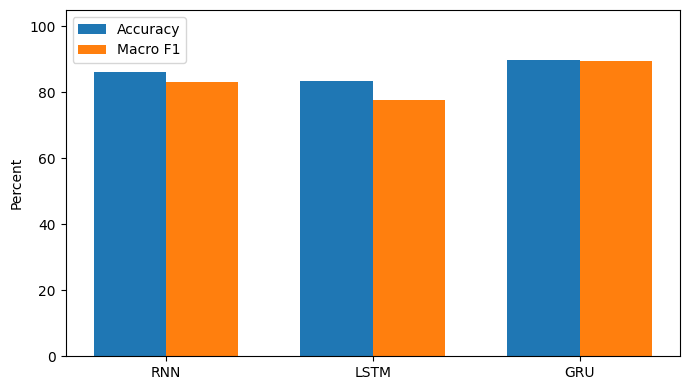

In [8]:
result_df=pd.DataFrame([{
    'Model':k,
    'Accuracy (%)':100*v['Accuracy'],
    'Macro Precision (%)':100*v['Precision'],
    'Macro Recall (%)':100*v['Recall'],
    'Macro F1 (%)':100*v['F1'],
    'Parameters':v['Parameters'],
    'Training Time (s)':v['TrainingTime']
} for k,v in metrics.items()])
print(result_df.round(3).to_string(index=False))

x=np.arange(3); w=0.35
plt.figure(figsize=(7,4))
plt.bar(x-w/2,result_df['Accuracy (%)'],w,label='Accuracy')
plt.bar(x+w/2,result_df['Macro F1 (%)'],w,label='Macro F1')
plt.xticks(x,result_df['Model']); plt.ylabel('Percent'); plt.ylim(0,105); plt.legend(); plt.tight_layout(); plt.savefig(f'{out_dir}/model_comparison.png',dpi=160); plt.show()

Model              GRU    LSTM     RNN
SequenceLength                        
32              0.7262  0.2049  0.7691
64              0.5556  0.5346  0.7778
128             0.6251  0.6111  0.6285


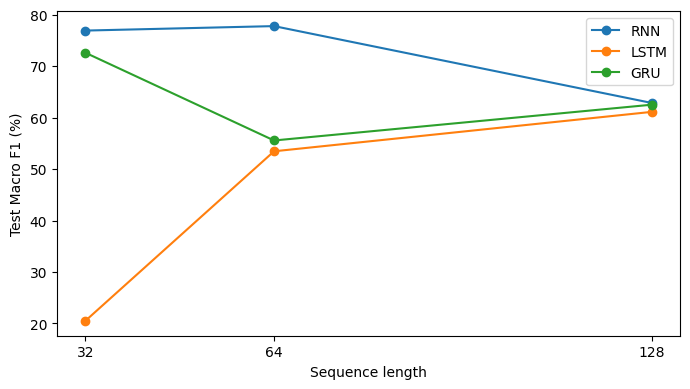

In [9]:
seq_results=[]
for L in [32,64,128]:
    for kind in ['RNN','LSTM','GRU']:
        m,h,tm=train_model(kind,X_train[:,:L],y_train,X_val[:,:L],y_val,3)
        acc,prec,rec,f1,cm,p=evaluate(m,X_test[:,:L],y_test)
        seq_results.append([L,kind,f1])
seq_df=pd.DataFrame(seq_results,columns=['SequenceLength','Model','F1'])
print(seq_df.pivot(index='SequenceLength',columns='Model',values='F1').round(4).to_string())
plt.figure(figsize=(7,4))
for kind in ['RNN','LSTM','GRU']:
    d=seq_df[seq_df.Model==kind]; plt.plot(d.SequenceLength,d.F1*100,marker='o',label=kind)
plt.xlabel('Sequence length'); plt.ylabel('Test Macro F1 (%)'); plt.xticks([32,64,128]); plt.legend(); plt.tight_layout(); plt.savefig(f'{out_dir}/sequence_length.png',dpi=160); plt.show()

In [10]:
def make_video(label,n=10,size=32):
    frames=[]
    for q in range(n):
        img=np.zeros((size,size),dtype=np.float32)
        if label==0: x=2+2*q; y=8
        elif label==1: x=8; y=2+2*q
        else: x=2+2*q; y=2+2*q
        x=min(x,size-7); y=min(y,size-7)
        img[y:y+6,x:x+6]=1.0
        img+=np.random.normal(0,0.03,img.shape).astype(np.float32)
        frames.append(np.clip(img,0,1))
    return np.array(frames)

VX=[]; VY=[]
for c in range(3):
    for i in range(60): VX.append(make_video(c)); VY.append(c)
VX=np.array(VX)[:, :, None, :, :]
VY=np.array(VY)
vi_train,vi_tmp=train_test_split(np.arange(len(VY)),test_size=0.30,stratify=VY,random_state=seed)
vi_val,vi_test=train_test_split(vi_tmp,test_size=0.50,stratify=VY[vi_tmp],random_state=seed)

class CNNFeature(nn.Module):
    def __init__(self):
        super().__init__(); self.net=nn.Sequential(nn.Conv2d(1,8,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(8,16,3,padding=1),nn.ReLU(),nn.AdaptiveAvgPool2d((4,4)))
    def forward(self,x): return self.net(x).flatten(1)
class FramePretrain(nn.Module):
    def __init__(self):
        super().__init__(); self.cnn=CNNFeature(); self.fc=nn.Linear(256,4)
    def forward(self,x): return self.fc(self.cnn(x))

FX=[]; FY=[]
for _ in range(600):
    img=np.zeros((32,32),dtype=np.float32); x0=np.random.randint(1,25); y0=np.random.randint(1,25); img[y0:y0+6,x0:x0+6]=1; img+=np.random.normal(0,0.03,img.shape); FX.append(np.clip(img,0,1)[None])
    FY.append((x0>=13)+2*(y0>=13))
FX=np.array(FX,dtype=np.float32); FY=np.array(FY,dtype=np.int64)
pre=FramePretrain(); opt=torch.optim.Adam(pre.parameters(),lr=2e-3); lossfn=nn.CrossEntropyLoss(); dl=DataLoader(TensorDataset(torch.tensor(FX),torch.tensor(FY)),64,shuffle=True)
for ep in range(3):
    for xb,yb in dl:
        opt.zero_grad(); l=lossfn(pre(xb),yb); l.backward(); opt.step()
cnn=pre.cnn
for p in cnn.parameters(): p.requires_grad=False
with torch.no_grad():
    z=cnn(torch.tensor(VX.reshape(-1,1,32,32))).reshape(len(VX),10,-1).numpy()
print('CNN feature dimension:',z.shape[-1])
print('Video recurrent input tensor:',z.shape)

class VideoGRU(nn.Module):
    def __init__(self,d):
        super().__init__(); self.gru=nn.GRU(d,32,batch_first=True); self.fc=nn.Linear(32,3)
    def forward(self,x): z,_=self.gru(x); return self.fc(z[:,-1])
vm=VideoGRU(z.shape[-1]); opt=torch.optim.Adam(vm.parameters(),lr=2e-3); lossfn=nn.CrossEntropyLoss()
tr=DataLoader(TensorDataset(torch.tensor(z[vi_train]),torch.tensor(VY[vi_train])),32,shuffle=True)
va=DataLoader(TensorDataset(torch.tensor(z[vi_val]),torch.tensor(VY[vi_val])),32)
vhist={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
st=time.perf_counter()
for ep in range(12):
    vm.train(); ls=[]; pr=[]; gt=[]
    for xb,yb in tr:
        opt.zero_grad(); o=vm(xb); l=lossfn(o,yb); l.backward(); opt.step(); ls.append(l.item()*len(yb)); pr+=o.argmax(1).tolist(); gt+=yb.tolist()
    vm.eval(); vls=[]; vpr=[]; vgt=[]
    with torch.no_grad():
        for xb,yb in va:
            o=vm(xb); l=lossfn(o,yb); vls.append(l.item()*len(yb)); vpr+=o.argmax(1).tolist(); vgt+=yb.tolist()
    vhist['train_loss'].append(sum(ls)/len(gt)); vhist['val_loss'].append(sum(vls)/len(vgt)); vhist['train_acc'].append(accuracy_score(gt,pr)); vhist['val_acc'].append(accuracy_score(vgt,vpr))
video_time=time.perf_counter()-st
vm.eval()
with torch.no_grad(): vp=vm(torch.tensor(z[vi_test])).argmax(1).numpy(); probs=torch.softmax(vm(torch.tensor(z[vi_test])),1).numpy()
vacc=accuracy_score(VY[vi_test],vp); vprec,vrec,vf1,_=precision_recall_fscore_support(VY[vi_test],vp,average='macro',zero_division=0); vcm=confusion_matrix(VY[vi_test],vp); vparams=sum(p.numel() for p in vm.parameters() if p.requires_grad)
print('Video Accuracy:',round(vacc,4),'Macro F1:',round(vf1,4),'Parameters:',vparams,'Training Time:',round(video_time,3))
print('Predicted class:', ['Horizontal','Vertical','Diagonal'][vp[0]])
print('Actual class:', ['Horizontal','Vertical','Diagonal'][VY[vi_test][0]])
print('Confidence:',round(float(probs[0].max()),4))

CNN feature dimension: 256
Video recurrent input tensor: (180, 10, 256)
Video Accuracy: 1.0 Macro F1: 1.0 Parameters: 27939 Training Time: 0.156
Predicted class: Vertical
Actual class: Vertical
Confidence: 0.9819


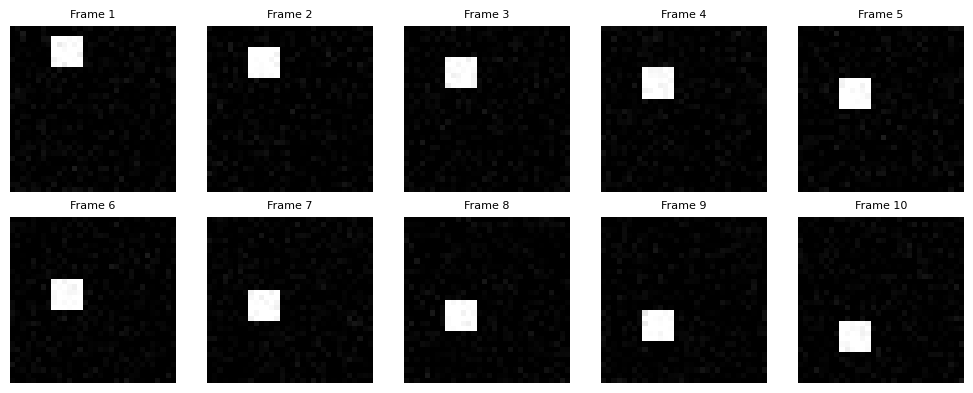

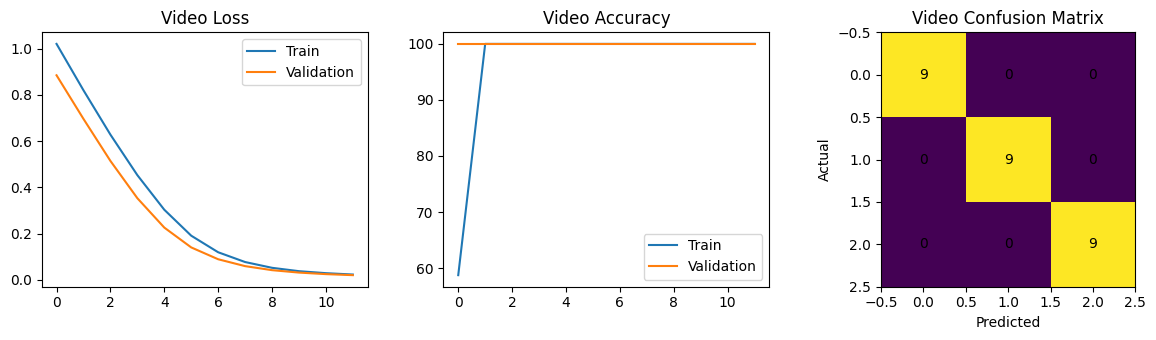

In [11]:
fig,axs=plt.subplots(2,5,figsize=(10,4))
for i,ax in enumerate(axs.ravel()): ax.imshow(VX[vi_test[0],i,0],cmap='gray'); ax.axis('off'); ax.set_title(f'Frame {i+1}',fontsize=8)
plt.tight_layout(); plt.savefig(f'{out_dir}/video_frames.png',dpi=160); plt.show()
fig,axs=plt.subplots(1,3,figsize=(12,3.5))
axs[0].plot(vhist['train_loss'],label='Train'); axs[0].plot(vhist['val_loss'],label='Validation'); axs[0].set_title('Video Loss'); axs[0].legend()
axs[1].plot(np.array(vhist['train_acc'])*100,label='Train'); axs[1].plot(np.array(vhist['val_acc'])*100,label='Validation'); axs[1].set_title('Video Accuracy'); axs[1].legend()
axs[2].imshow(vcm); axs[2].set_title('Video Confusion Matrix'); axs[2].set_xlabel('Predicted'); axs[2].set_ylabel('Actual')
for i in range(3):
    for j in range(3): axs[2].text(j,i,vcm[i,j],ha='center',va='center')
plt.tight_layout(); plt.savefig(f'{out_dir}/video_results.png',dpi=160); plt.show()

Token accuracy: 0.988
Sequence accuracy: 0.9778
Final training loss: 0.0859
Final validation loss: 0.0897
1 [3, 2, 6, 5] -> [5, 6, 2, 3] expected [5, 6, 2, 3]
2 [8, 4, 8, 4] -> [4, 8, 4, 8] expected [4, 8, 4, 8]
3 [6, 8, 3, 3] -> [3, 3, 8, 6] expected [3, 3, 8, 6]
4 [6, 3, 6, 4] -> [4, 6, 3, 6] expected [4, 6, 3, 6]
5 [4, 4, 4, 1] -> [1, 4, 4, 4] expected [1, 4, 4, 4]


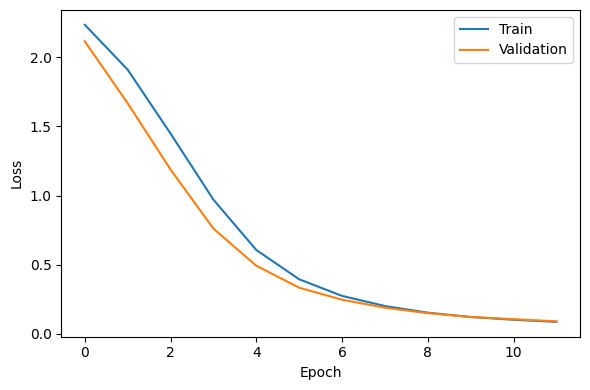

In [12]:
vocab=10
L=4
n=1800
SX=np.random.randint(1,vocab,size=(n,L),dtype=np.int64)
SY=SX[:,::-1].copy()
si_train,si_tmp=train_test_split(np.arange(n),test_size=0.30,random_state=seed)
si_val,si_test=train_test_split(si_tmp,test_size=0.50,random_state=seed)
class ReverseSeq(nn.Module):
    def __init__(self):
        super().__init__(); self.emb=nn.Embedding(vocab,16); self.enc=nn.LSTM(16,32,batch_first=True); self.dec=nn.LSTM(16,32,batch_first=True); self.fc=nn.Linear(32,vocab)
    def forward(self,x,target=None):
        e=self.emb(x); _,state=self.enc(e); start=torch.zeros((x.shape[0],1),dtype=torch.long); outs=[]; inp=start
        for k in range(L):
            d,state=self.dec(self.emb(inp),state); o=self.fc(d[:,-1]); outs.append(o); inp=(target[:,k:k+1] if target is not None else o.argmax(1,keepdim=True))
        return torch.stack(outs,1)
sm=ReverseSeq(); opt=torch.optim.Adam(sm.parameters(),lr=3e-3); lossfn=nn.CrossEntropyLoss()
tr=DataLoader(TensorDataset(torch.tensor(SX[si_train]),torch.tensor(SY[si_train])),64,shuffle=True)
va=DataLoader(TensorDataset(torch.tensor(SX[si_val]),torch.tensor(SY[si_val])),64)
sh={'train_loss':[],'val_loss':[]}
for ep in range(12):
    sm.train(); ls=[]; count=0
    for xb,yb in tr:
        opt.zero_grad(); o=sm(xb,yb); l=lossfn(o.reshape(-1,vocab),yb.reshape(-1)); l.backward(); opt.step(); ls.append(l.item()*len(yb)); count+=len(yb)
    sm.eval(); vls=[]; vc=0
    with torch.no_grad():
        for xb,yb in va:
            o=sm(xb,yb); l=lossfn(o.reshape(-1,vocab),yb.reshape(-1)); vls.append(l.item()*len(yb)); vc+=len(yb)
    sh['train_loss'].append(sum(ls)/count); sh['val_loss'].append(sum(vls)/vc)
sm.eval()
with torch.no_grad(): so=sm(torch.tensor(SX[si_test]),None).argmax(2).numpy()
token_acc=(so==SY[si_test]).mean(); seq_acc=(so==SY[si_test]).all(axis=1).mean()
print('Token accuracy:',round(float(token_acc),4))
print('Sequence accuracy:',round(float(seq_acc),4))
print('Final training loss:',round(sh['train_loss'][-1],4))
print('Final validation loss:',round(sh['val_loss'][-1],4))
for i in range(5): print(i+1,SX[si_test][i].tolist(),'->',so[i].tolist(),'expected',SY[si_test][i].tolist())
plt.figure(figsize=(6,4)); plt.plot(sh['train_loss'],label='Train'); plt.plot(sh['val_loss'],label='Validation'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout(); plt.savefig(f'{out_dir}/seq2seq_loss.png',dpi=160); plt.show()

In [13]:
summary={
'har':{k:{kk:(float(vv) if isinstance(vv,(float,np.floating)) else int(vv)) for kk,vv in v.items() if kk!='CM'} for k,v in metrics.items()},
'manual_h':vals,
'sequence_length':seq_df.to_dict(orient='records'),
'video':{'Accuracy':float(vacc),'Precision':float(vprec),'Recall':float(vrec),'F1':float(vf1),'Parameters':int(vparams),'TrainingTime':float(video_time),'FeatureDim':int(z.shape[-1]),'InputShape':list(z.shape),'ConfusionMatrix':vcm.tolist(),'SamplePred':int(vp[0]),'SampleActual':int(VY[vi_test][0]),'SampleConfidence':float(probs[0].max())},
'seq2seq':{'TokenAccuracy':float(token_acc),'SequenceAccuracy':float(seq_acc),'TrainLoss':float(sh['train_loss'][-1]),'ValLoss':float(sh['val_loss'][-1]),'Examples':[{'input':SX[si_test][i].tolist(),'pred':so[i].tolist(),'expected':SY[si_test][i].tolist()} for i in range(5)]},
'class_names':classes,
'har_confusions':{k:v['CM'].tolist() for k,v in metrics.items()}
}
import json
with open(f'{out_dir}/summary.json','w') as f: json.dump(summary,f,indent=2)
print('Saved summary.json')

Saved summary.json
